In [1]:
#!pip install pystac_client
#!pip install planetary_computer

In [2]:
import pystac_client
import planetary_computer as pc
import rioxarray
import xarray as xr
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt
import folium
import requests
from shapely.geometry import mapping

In [3]:
### Define a box representing the area of interest (AOI)

# Example: small region in San Francisco
aoi = box(-122.50, 37.75, -122.40, 37.85)
gdf = gpd.GeoDataFrame({"geometry": [aoi]}, crs="EPSG:4326")

print(gdf)
gdf.explore()


                                            geometry
0  POLYGON ((-122.4 37.75, -122.4 37.85, -122.5 3...


In [4]:
### Search Planetary Computer STAC for Sentinel-2 L2A Data using the AOI

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1"
)

search = catalog.search(
    collections=["sentinel-2-l2a"],
    intersects=gdf.geometry.iloc[0],
    datetime="2023-06-01/2023-06-30",
    query={"eo:cloud_cover": {"lt": 20}},
)

items = list(search.get_items())
item = items[0]
signed_item = pc.sign(item)

item


C:\Users\snd21\anaconda3\Lib\site-packages\pystac_client\item_search.py:925: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(


<Item id=S2A_MSIL2A_20230618T184921_R113_T10SEG_20230619T034036>

In [5]:
### Render a quick preview (rendered preview + tile layer)

from IPython.display import Image
Image(url=item.assets["rendered_preview"].href, width=500)


In [6]:
### Generate an Interactive Map with tile overlay

# Interactive map with tile overlay
tilejson = requests.get(item.assets["tilejson"].href).json()
tiles = tilejson["tiles"][0]

center = (
    (item.bbox[1] + item.bbox[3]) / 2,
    (item.bbox[0] + item.bbox[2]) / 2,
)

m = folium.Map(location=center, zoom_start=11)
folium.TileLayer(tiles=tiles, attr="Planetary Computer").add_to(m)

folium.GeoJson(
    mapping(gdf.geometry.iloc[0]),
    style_function=lambda x: {"color": "red", "weight": 3}
).add_to(m)

m

In [7]:
### Load various bands of interest (raw and full res)

# 10m bands
red   = rioxarray.open_rasterio(signed_item.assets["B04"].href, masked=True).squeeze()
nir   = rioxarray.open_rasterio(signed_item.assets["B08"].href, masked=True).squeeze()
blue  = rioxarray.open_rasterio(signed_item.assets["B02"].href, masked=True).squeeze()
green = rioxarray.open_rasterio(signed_item.assets["B03"].href, masked=True).squeeze()

# 20m band (SWIR2)
swir2 = rioxarray.open_rasterio(signed_item.assets["B12"].href, masked=True).squeeze()

# Scene Classification Layer (modern replacement for QA60)
scl   = rioxarray.open_rasterio(signed_item.assets["SCL"].href, masked=True).squeeze()


In [8]:
### Reproject AOI to match the CRS of the raster

gdf_utm = gdf.to_crs(red.rio.crs)


In [9]:
### Clip bands at their native resolution

# Clip 10m bands
red_c   = red.rio.clip(gdf_utm.geometry)
nir_c   = nir.rio.clip(gdf_utm.geometry)
blue_c  = blue.rio.clip(gdf_utm.geometry)
green_c = green.rio.clip(gdf_utm.geometry)

# Clip 20m bands BEFORE resampling
swir2_c = swir2.rio.clip(gdf_utm.geometry)
scl_c   = scl.rio.clip(gdf_utm.geometry)

# Resample 20m bands to 10m after clip
swir2_10 = swir2_c.rio.reproject_match(nir_c)
scl_10   = scl_c.rio.reproject_match(nir_c)



In [10]:
### Apply reflectance scale factor

scale = 0.0001

red_s   = red_c.astype("float32")    * scale
nir_s   = nir_c.astype("float32")    * scale
blue_s  = blue_c.astype("float32")   * scale
green_s = green_c.astype("float32")  * scale
swir2_s = swir2_10.astype("float32") * scale


In [11]:
### Compute and apply cloud masking using SCL

# SCL classes to mask:
# 3 = cloud shadow
# 8 = medium cloud
# 9 = high cloud
# 10 = cirrus
# 11 = snow/ice

cloud_classes = [3, 8, 9, 10, 11]  # shadow, medium cloud, high cloud, cirrus, snow

cloud_mask = ~scl_10.isin(cloud_classes)

red_m   = red_s.where(cloud_mask)
nir_m   = nir_s.where(cloud_mask)
blue_m  = blue_s.where(cloud_mask)
green_m = green_s.where(cloud_mask)
swir2_m = swir2_s.where(cloud_mask)


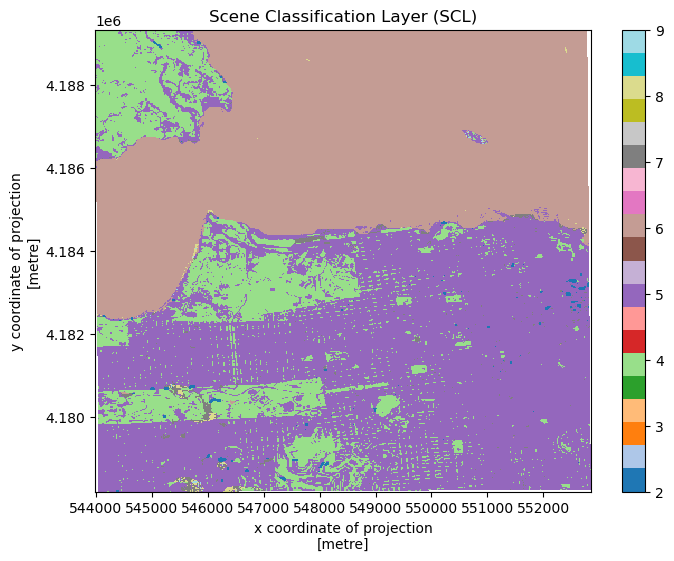

In [12]:
### Visualize SCL (Scene Classification Layer)

plt.figure(figsize=(8,6))
scl_10.plot(cmap="tab20", add_colorbar=True)
plt.title("Scene Classification Layer (SCL)")
plt.show()

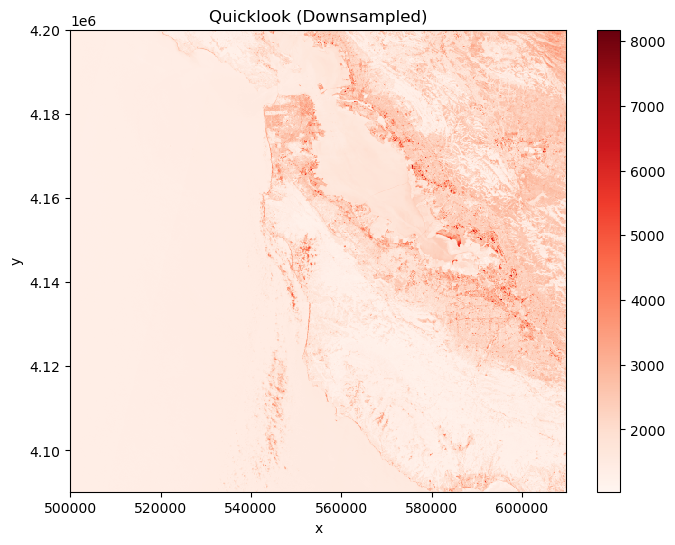

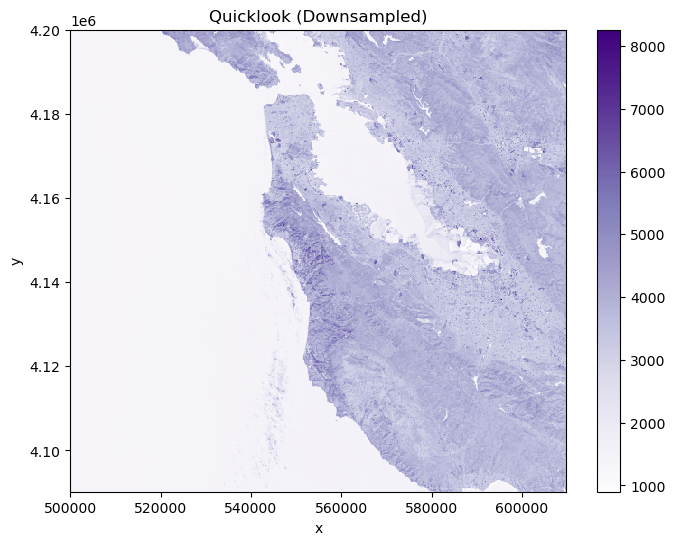

In [13]:
### Quicklook Helper function

def quicklook(xarr, factor=20, cmap="gray"):
    ds = xarr.coarsen(x=factor, y=factor, boundary="trim").mean()
    plt.figure(figsize=(8,6))
    ds.plot(cmap=cmap)
    plt.title("Quicklook (Downsampled)")
    plt.show()

quicklook(red, cmap="Reds")
quicklook(nir, cmap="Purples")

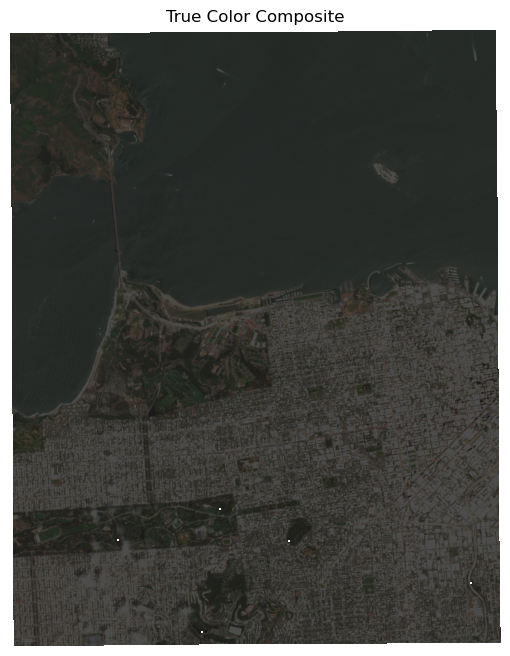

In [14]:
### RGB Composite

rgb = xr.concat([red_s, green_s, blue_s], dim="band").transpose("y", "x", "band")

plt.figure(figsize=(8,8))
plt.imshow(rgb.clip(0, 0.3))
plt.title("True Color Composite")
plt.axis("off")
plt.show()

# Spectral Indices

## 1) NDVI - Normalized Difference Vegetation Index

NDVI is a measure of "vegetation greenness" - essentially it is a marker for the amount of healthy vegetation.
- Healthy vegetation absorbs red light (for photosynthesis)
- Healthy vegetation reflects near-infrared (NIR)

The contrast between NIR and Red makes a strong vegetation signal

NVDI = (NIR - Red) / (NIR + Red)

Typical values for NVDI:
- 0.6 - 0.9 -> dense and healthy vegetation
- 0.2 - 0.5 -> sparse or stressed vegetation
- 0.0 - 0.2 -> soil or dry grass or urban surfaces
- < 0 -> water, shadows and / or clouds

## 2) EVI - Enhanced Vegetation Index

EVI is another measure of vegetation which is designed to compensate for areas where NVDI saturates and becomes less sensitive.

NVDI becomes less sensitive in areas containing:
- Rainforests
- Dense tree canopies
- Areas with strong atmospheric effects

EVI is a spectral indicator which adds a blue band to correct for atmospheric saturation and other coefficients to reduce saturation

EVI = 2.5 * (NIR - Red) / (NIR + 6 * Red - 7.5 * Blue + 1)

Typical values for EVI:
- 0.3 - 0.8 -> healthy vegetation
- 0.0 - 0.2 -> sparse vegetation
- < 0 -> non-vegetation

## 3) NDWI - Normalized Difference Water Index

NDWI is used to detect bodies of water and moisture content. It is often used for mapping / detection purposes for lakes, rivers or reservoirs. It is also helpful in flood detection and wetland monitoring.

NDWI is computed based on the NIR and Green bands
- Water strongly absorbs NIR
- Water reflects Green

NDWI = (Green - NIR) / (Green + NIR)

Typical values for NDWI:
- 0.3 - 1.0 -> water
- 0.0 - 0.3 -> moise vegetation
- < 0 -> soil or urban surfaces

## 4) NBR - Normalized Burn Ratio

NBR is designed as measure of burn severity and fire damage assessment. 

It works by looking at the contrast between the NIR and SWIR2 bands:
- Vegetation is usually destroyed by fire -> NIR decreases
- Char and Ash are produced by fire -> Char and Ash reflect strongly in SWIR2, so SWIR2 increases

NBR = (NIR - SWIR2) / (NIR + SWIR2)

Typical values for NBR:
- 0.5 - 1.0 -> healthy vegetation
- 0.1 - 0.5 -> unburned vegetation
- 0.0 - 0.1 -> low burn severity
- < 0 -> high burn severity

## General Notes
- Note that when computing any of the spectral indices, it is important to make sure that the resolution of all the bands is the same.
- Depending on the source of the raster data, it may also be necessary to apply a reflectance scale factor to the raw raster data prior to computing the various indices.


# 📘 Spectral Index Reference Table (Sentinel‑2)

This notebook computes a suite of commonly used spectral indices.  
The table below summarizes **what each index measures**, **how it works**, **typical value ranges**, and **best use cases**.

| **Index** | **Formula** | **Description** | **Typical Values** | **Meaning of Values** | **Best Use Cases** |
|-----------|-------------|-----------------|--------------------|------------------------|---------------------|
| **NDVI — Normalized Difference Vegetation Index** | (NIR − Red) / (NIR + Red) | NDVI measures vegetation “greenness,” a proxy for healthy vegetation.<br>- Healthy vegetation absorbs Red (photosynthesis)<br>- Healthy vegetation reflects NIR<br>The contrast between NIR and Red produces a strong vegetation signal. | <0 → water/shadow<br>0–0.2 → soil/urban<br>0.2–0.5 → grass/shrubs<br>0.5–0.8 → healthy vegetation | Higher = more photosynthetic activity | Vegetation health, crop monitoring, drought |
| **EVI — Enhanced Vegetation Index** | 2.5·(NIR − Red) / (NIR + 6·Red − 7.5·Blue + 1) | The Enhanced Vegetation Index (EVI) improves on NDVI in dense vegetation and hazy conditions.<br>- Uses Blue band to correct atmospheric scattering<br>- Reduces saturation in dense canopies | <0 → water<br>0–0.2 → soil<br>0.2–0.5 → moderate vegetation<br>0.5–0.9 → dense vegetation | Better performance in dense canopy | Tropical forests, dense vegetation |
| **SAVI — Soil Adjusted Vegetation Index** | 1.5·(NIR − Red) / (NIR + Red + 0.5) | The Soil Adjusted Vegetation Index (SAVI) corrects NDVI for soil brightness.<br>- Useful where soil is visible<br>- Reduces soil influence using a correction factor | <0.1 → soil<br>0.1–0.3 → sparse vegetation<br>0.3–0.6 → moderate vegetation<br>>0.6 → dense vegetation | Soil‑corrected vegetation greenness | Semi‑arid regions, early‑season crops |
| **NDRE — Normalized Difference Red Edge** | (NIR − RedEdge) / (NIR + RedEdge) | The Normalized Difference Red Edge Index (NDRE) uses the red‑edge band, which is sensitive to chlorophyll content.<br>- Detects stress earlier than NDVI<br>- Good for nutrient and canopy health | <0.1 → soil<br>0.1–0.3 → stressed vegetation<br>0.3–0.6 → healthy vegetation<br>>0.6 → high chlorophyll | Early stress detection | Precision agriculture, nutrient stress |
| **NDWI — Normalized Difference Water Index (McFeeters)** | (Green − NIR) / (Green + NIR) | The Normalized Difference Water Index (NDWI) highlights open water.<br>- Water reflects Green<br>- Water absorbs NIR<br>This contrast makes water stand out clearly. | >0.3 → water<br>0–0.3 → wet soil<br><0 → vegetation/urban | Higher = more water content | Water body extraction, flood mapping |
| **MNDWI — Modified Normalized Difference Water Index** | (Green − SWIR1) / (Green + SWIR1) | The Modified NDWI (MNDWI) improves water detection in urban areas.<br>- SWIR1 strongly suppresses built‑up surfaces<br>- Water remains bright | >0.3 → water<br><0 → urban/soil | Better water detection in urban areas | Urban flood mapping, wetlands |
| **NDMI — Normalized Difference Moisture Index** | (NIR − SWIR1) / (NIR + SWIR1) | The Normalized Difference Moisture Index (NDMI) measures vegetation moisture.<br>- Moist vegetation reflects NIR<br>- Dry vegetation reflects more SWIR1 | >0.3 → moist vegetation<br>0.1–0.3 → moderate moisture<br><0.1 → dry vegetation<br><0 → very dry | Higher = more moisture | Drought, fire risk, crop moisture |
| **NBR — Normalized Burn Ratio** | (NIR − SWIR2) / (NIR + SWIR2) | The Normalized Burn Ratio (NBR) is designed for burn severity and fire damage assessment.<br>- Fire destroys vegetation → NIR decreases<br>- Char and ash reflect strongly in SWIR2 → SWIR2 increases<br>The contrast reveals burn severity. | >0.1 → healthy vegetation<br>0–0.1 → stressed vegetation<br><0 → burned<br><−0.1 → severe burn | Burn severity mapping | Wildfire assessment, post‑fire recovery |
| **NBR2 — Normalized Burn Ratio 2** | (SWIR1 − SWIR2) / (SWIR1 + SWIR2) | NBR2 (Normalized Burn Ratio 2) enhances detection of severe burns and exposed soil.<br>- SWIR bands respond strongly to char and ash<br>- Useful when NBR saturates | >0.1 → unburned<br>0–0.1 → moderate disturbance<br><0 → severe burn<br><−0.1 → extreme burn | Sensitive to char & ash | High‑severity burn detection |
| **BAI — Bare Soil Index** | 1 / ((0.1 − Red)² + (0.06 − NIR)²) | The Bare Soil Index (BAI) highlights bare soil using a geometric distance in Red–NIR space.<br>- Soil has a characteristic reflectance “signature”<br>- Higher values = more soil | High → bare soil<br>Moderate → sparse vegetation<br>Low → dense vegetation or water | Soil exposure mapping | Desertification, land degradation |
| **NDBI — Normalized Difference Built‑up Index** | (SWIR1 − NIR) / (SWIR1 + NIR) | The Normalized Difference Built‑up Index (NDBI) identifies urban/built‑up areas.<br>- Urban surfaces reflect SWIR strongly<br>- Vegetation reflects NIR strongly<br>The contrast separates built vs. vegetated pixels. | >0.1 → built‑up<br>0–0.1 → mixed pixels<br><0 → vegetation/water | Higher = more urbanization | Urban mapping, impervious surfaces |

---


In [15]:
### Compute spectral indices

# NDVI
ndvi = (nir_m - red_m) / (nir_m + red_m)

# EVI
evi = 2.5 * (nir_m - red_m) / (nir_m + 6*red_m - 7.5*blue_m + 1)

# NDWI
ndwi = (green_m - nir_m) / (green_m + nir_m)

# NBR
nbr = (nir_m - swir2_m) / (nir_m + swir2_m)


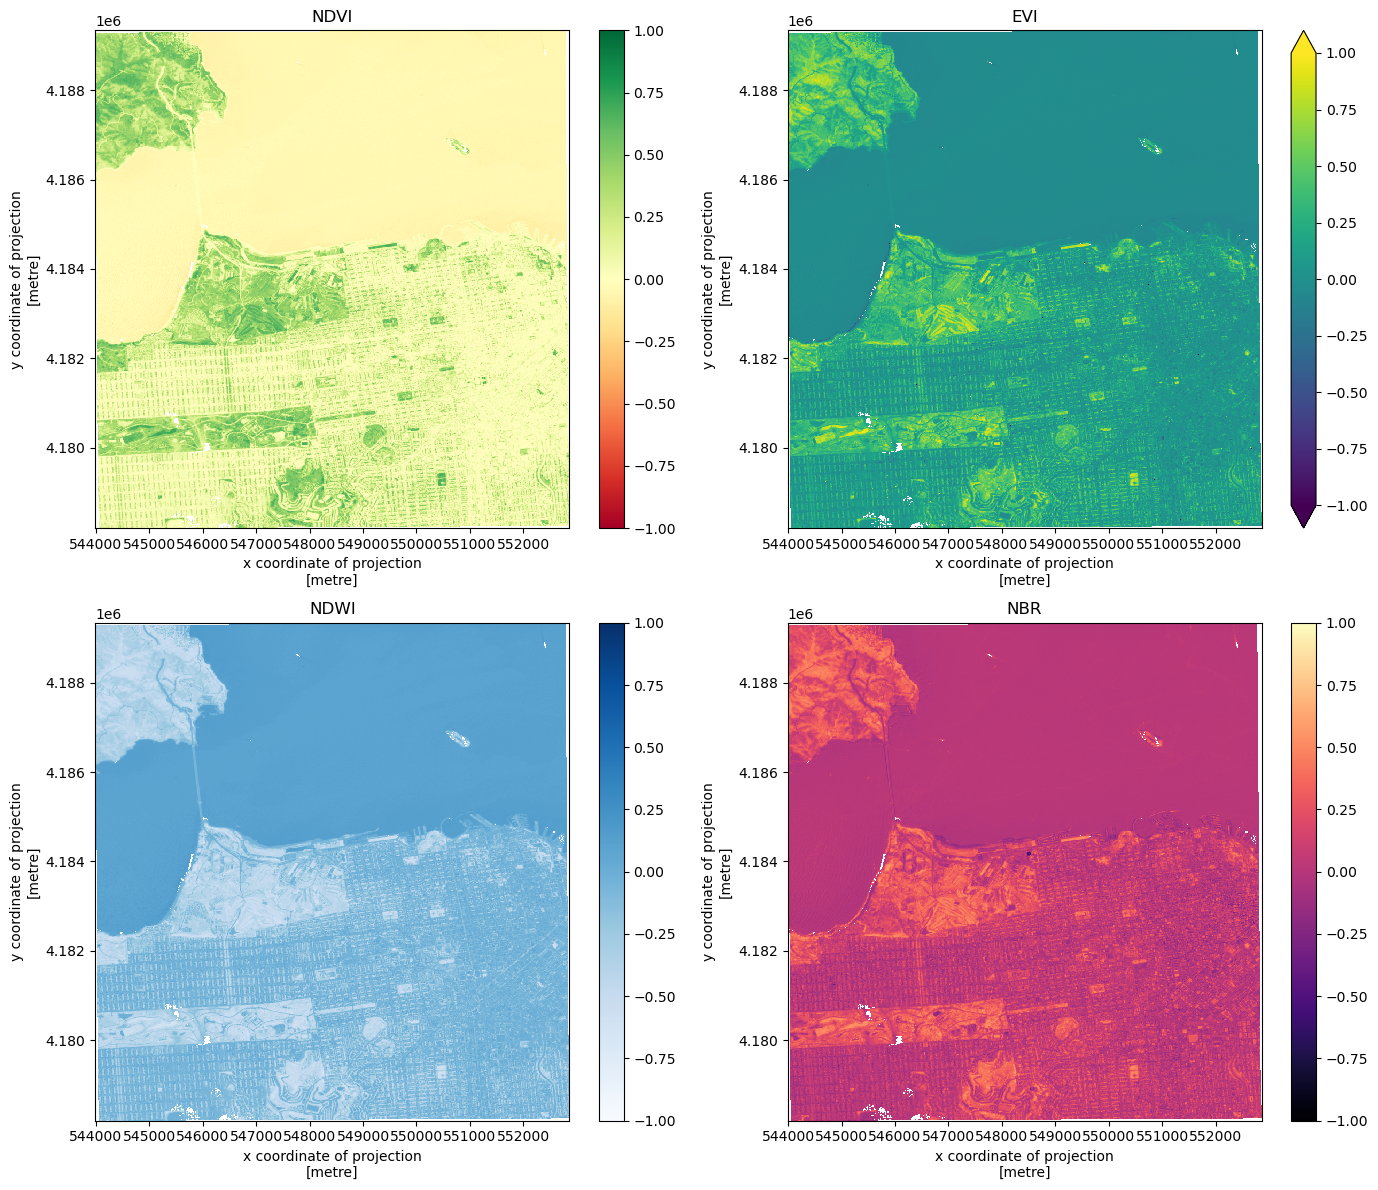

In [16]:
### Plot all spectral indices

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

ndvi.plot(ax=axes[0,0], cmap="RdYlGn", vmin=-1, vmax=1)
axes[0,0].set_title("NDVI")

evi.plot(ax=axes[0,1], cmap="viridis", vmin=-1, vmax=1)
axes[0,1].set_title("EVI")

ndwi.plot(ax=axes[1,0], cmap="Blues", vmin=-1, vmax=1)
axes[1,0].set_title("NDWI")

nbr.plot(ax=axes[1,1], cmap="magma", vmin=-1, vmax=1)
axes[1,1].set_title("NBR")

plt.tight_layout()
plt.show()


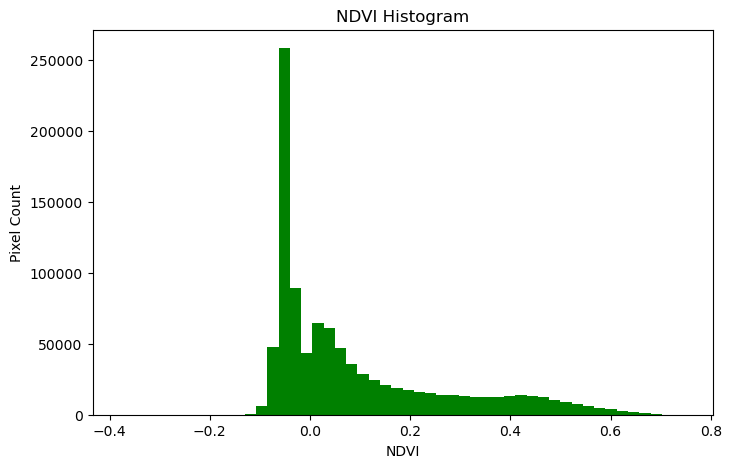

In [17]:
### NDVI Histogram

"""
This histogram shows the distribution of NVDI values across the AOI. This can be used as a 'global summary' of the scene at a glance.

This can be used to help determine the composition of the AOI:
 - How much vegetation exists: A strong peak around 0.5 - 0.8 can indicate lots of healthy vegetation.
 - How urban the area is: A peak around 0.0 - 0.2 can indicate lots of impervious surfaces.
 - Presence of water: A spike below 0.0 can indicate water or deep shadows
 - Vegetation stress: If comparing rasters for the same AOI over time, a shift in the vegetation peak towards lower values 
   might indicate drought or seasonal changes
 - Scene quality: An odd distribution (eg. lots of extreme values, or many peaks) can indicate an issue with the raster or computation of NVDI
   including cloud contamination, unscaled reflectance, clipping errors, misalignment, etc.

"""


plt.figure(figsize=(8,5))
ndvi.plot.hist(bins=50, color="green")
plt.title("NDVI Histogram")
plt.xlabel("NDVI")
plt.ylabel("Pixel Count")
plt.show()


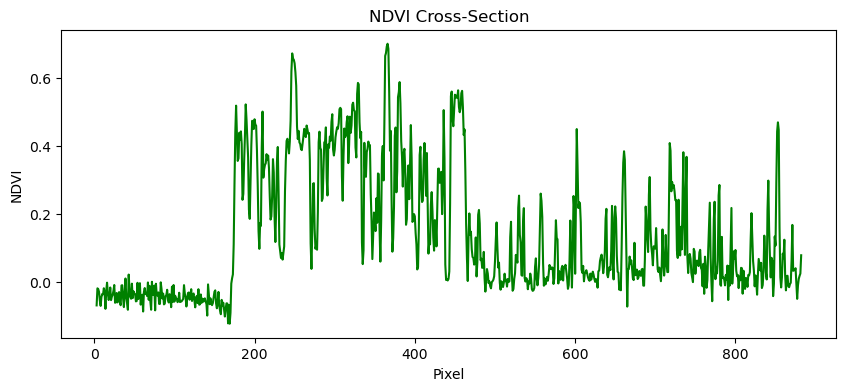

In [18]:
### NDVI Cross Section

"""
NVDI cross-section is a 1D slice through the raster. It shows how NVDI changes along a line (eg. east -> west across the AOI).

This can be used to learn about spatial transitions in the raster (eg. vegetation -> buildings -> vegetation -> water) as peaks and dips. This can also
be used to help identify sharp boundaries (sudden drops that might indicate roads, building edges, water boundaries, etc.)
"""


row = int(ndvi.shape[0] / 2)

plt.figure(figsize=(10,4))
plt.plot(ndvi[row, :], color="green")
plt.title("NDVI Cross-Section")
plt.xlabel("Pixel")
plt.ylabel("NDVI")
plt.show()
